In [1]:
import os
import pickle
import random
import gc

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)

from scipy.stats import skew, mode, kurtosis
from tqdm import tqdm

# NOTE:
# The original cell crashed with:
#   AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
# In Kaggle environments this is often triggered by importing pydicom (protobuf dependency mismatch).
# To keep core logic intact but unblock execution, we *defer* importing pydicom/cv2/plt/sns until
# the image feature pipeline is actually invoked.
#
# We also keep the rest of imports as-is for tabular + TF model.

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Lambda,
    Dropout,
    BatchNormalization,
    GaussianDropout,
)
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras.callbacks import Callback

SEED = 1337


def seed_everything(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def get_competition_root():
    # Keep original ../input/... paths working on Kaggle, but also support provided /kaggle/input layout.
    preferred = "../input/osic-pulmonary-fibrosis-progression"
    fallback = "/kaggle/input/osic-pulmonary-fibrosis-progression"
    return preferred if os.path.exists(preferred) else fallback


COMP_ROOT = get_competition_root()
print("COMP_ROOT =", COMP_ROOT)



2026-05-12 03:00:21.414589: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 03:00:21.425741: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778554821.437071      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778554821.440450      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 03:00:21.453590: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

COMP_ROOT = ../input/osic-pulmonary-fibrosis-progression


In [2]:
df_train = pd.read_csv(f"{COMP_ROOT}/train.csv")
df_test = pd.read_csv(f"{COMP_ROOT}/test.csv")
df_submission = pd.read_csv(f"{COMP_ROOT}/sample_submission.csv")

print(
    f'Training Set Shape = {df_train.shape} - Patients = {df_train["Patient"].nunique()}'
)
print(f"Training Set Memory Usage = {df_train.memory_usage().sum() / 1024 ** 2:.2f} MB")
print(f'Test Set Shape = {df_test.shape} - Patients = {df_test["Patient"].nunique()}')
print(f"Test Set Memory Usage = {df_test.memory_usage().sum() / 1024 ** 2:.2f} MB")
print(f"Sample Submission Shape = {df_submission.shape}")
print(
    f"Sample Submission Memory Usage = {df_submission.memory_usage().sum() / 1024 ** 2:.2f} MB"
)




Training Set Shape = (1394, 7) - Patients = 158
Training Set Memory Usage = 0.07 MB
Test Set Shape = (18, 7) - Patients = 18
Test Set Memory Usage = 0.00 MB
Sample Submission Shape = (1908, 3)
Sample Submission Memory Usage = 0.04 MB


In [3]:
class TabularDataPreprocessor:

    def __init__(self, train, test, submission, n_folds, shuffle, ohe, scale):

        self.train = train.copy(deep=True)
        self.train.sort_values(by=["Patient", "Weeks"], inplace=True)
        self.test = test.copy(deep=True)
        self.submission = submission.copy(deep=True)

        self.n_folds = n_folds
        self.shuffle = shuffle

        self.ohe = ohe
        self.scale = scale

    def drop_duplicates(self):
        self.train["FVC"] = self.train.groupby(["Patient", "Weeks"])["FVC"].transform(
            "mean"
        )
        self.train["Percent"] = self.train.groupby(["Patient", "Weeks"])[
            "Percent"
        ].transform("mean")
        self.train.drop_duplicates(inplace=True)
        self.train.reset_index(drop=True, inplace=True)

    def label_encode(self):
        for df in [self.train, self.test]:
            df["Sex"] = df["Sex"].map({"Male": 0, "Female": 1})
            df["Sex"] = df["Sex"].astype(np.uint8)
            df["SmokingStatus"] = df["SmokingStatus"].map(
                {"Never smoked": 0, "Ex-smoker": 1, "Currently smokes": 2}
            )
            df["SmokingStatus"] = df["SmokingStatus"].astype(np.uint8)

    def one_hot_encode(self):
        for df in [self.train, self.test]:
            df["Male"] = 0
            df["Female"] = 0
            df.loc[df["Sex"] == 0, "Male"] = 1
            df.loc[df["Sex"] == 1, "Female"] = 1

            df["Never smoked"] = 0
            df["Ex-smoker"] = 0
            df["Currently smokes"] = 0
            df.loc[df["SmokingStatus"] == 0, "Never smoked"] = 1
            df.loc[df["SmokingStatus"] == 1, "Ex-smoker"] = 1
            df.loc[df["SmokingStatus"] == 2, "Currently smokes"] = 1

            df.drop(columns=["Sex", "SmokingStatus"], inplace=True)

            for encoded_col in [
                "Male",
                "Female",
                "Never smoked",
                "Ex-smoker",
                "Currently smokes",
            ]:
                df[encoded_col] = df[encoded_col].astype(np.uint8)

    def create_folds(self):
        self.train["Sex_SmokingStatus"] = (
            self.train["Sex"].astype(str)
            + "_"
            + self.train["SmokingStatus"].astype(str)
        )
        for group in self.train["Sex_SmokingStatus"].unique():
            patients = self.train[self.train["Sex_SmokingStatus"] == group][
                "Patient"
            ].unique()

            if self.shuffle:
                np.random.seed(SEED)
                np.random.shuffle(patients)

            for fold, patient_group in enumerate(
                np.array_split(patients, self.n_folds), 1
            ):
                self.train.loc[
                    self.train["Patient"].isin(patient_group), "CV1_Fold"
                ] = fold

        # BUGFIX: sklearn removed LinearRegression(normalize=...) in newer versions.
        # This preserves core logic (simple linear fit on last 2 points) while unblocking execution.
        for patient_name in self.train["Patient"].unique():
            vals = self.train[(self.train["Patient"] == patient_name)]["FVC"].values[
                -2:
            ]
            std = vals.std()
            if std == 0:
                z = np.zeros_like(vals, dtype=np.float32)
            else:
                z = (vals - vals.mean()) / std
            reg = LinearRegression().fit(
                self.train[(self.train["Patient"] == patient_name)]["Weeks"]
                .values[-2:]
                .reshape(-1, 1),
                z,
            )

            self.train.loc[self.train["Patient"] == patient_name, "Intercept"] = (
                reg.intercept_
            )
            self.train.loc[self.train["Patient"] == patient_name, "Coef"] = reg.coef_[0]

        self.train.loc[self.train["Coef"] > 0.4, "Cluster"] = 1
        self.train.loc[
            (self.train["Coef"] < 0.4) & (self.train["Coef"] > -0.4), "Cluster"
        ] = 2
        self.train.loc[self.train["Coef"] < -0.4, "Cluster"] = 3

        for group in self.train["Cluster"].unique():
            patients = self.train[self.train["Cluster"] == group]["Patient"].unique()

            if self.shuffle:
                np.random.seed(SEED)
                np.random.shuffle(patients)

            for fold, patient_group in enumerate(
                np.array_split(patients, self.n_folds), 1
            ):
                self.train.loc[
                    self.train["Patient"].isin(patient_group), "CV2_Fold"
                ] = fold

        patients = self.train["Patient"].unique()
        np.random.seed(SEED)
        np.random.shuffle(patients)

        for fold, patient_group in enumerate(np.array_split(patients, self.n_folds), 1):
            self.train.loc[self.train["Patient"].isin(patient_group), "CV3_Fold"] = fold

        self.train.drop(
            columns=["Sex_SmokingStatus", "Intercept", "Coef", "Cluster"], inplace=True
        )

    def create_tabular_features(self):

        self.drop_duplicates()
        self.create_folds()
        self.label_encode()
        if self.ohe:
            self.one_hot_encode()

        self.train["Type"] = "Train"
        self.train["Weeks_Passed"] = self.train["Weeks"] - self.train.groupby(
            "Patient"
        )["Weeks"].transform("min")
        self.train["FVC_Baseline"] = self.train.groupby("Patient")["FVC"].transform(
            "first"
        )

        self.submission["Type"] = "Test"
        self.submission["Patient"] = (
            self.submission["Patient_Week"].apply(lambda x: x.split("_")[0]).astype(str)
        )
        self.submission["Weeks"] = (
            self.submission["Patient_Week"].apply(lambda x: x.split("_")[1]).astype(int)
        )
        self.submission.drop(
            columns=["Patient_Week", "FVC", "Confidence"], inplace=True
        )
        self.test = self.submission.merge(
            self.test.rename(
                columns={"Weeks": "Weeks_Baseline", "FVC": "FVC_Baseline"}
            ),
            how="left",
            on="Patient",
        )
        self.test["Weeks_Passed"] = self.test["Weeks"] - self.test["Weeks_Baseline"]
        self.test.drop(columns=["Weeks_Baseline"], inplace=True)

        df_all = pd.concat([self.train, self.test], ignore_index=True, axis=0)

        df_all["Age"] += df_all["Weeks_Passed"] / 52
        df_all["Age"] = df_all["Age"].astype(np.float32)
        df_all["FVC_Baseline"] = df_all["FVC_Baseline"].astype(np.float32)
        df_all["Percent"] = df_all["Percent"].astype(np.float32)
        df_all["Weeks_Passed"] = df_all["Weeks_Passed"].astype(np.float32)
        df_all["Weeks"] = df_all["Weeks"].astype(np.int16)

        df_all["FVC"] = df_all["FVC"].astype(np.float32)

        if self.scale:
            scale_features = ["Age", "FVC_Baseline", "Percent", "Weeks_Passed"]
            scaler = MinMaxScaler()
            df_all.loc[:, scale_features] = scaler.fit_transform(
                df_all.loc[:, scale_features]
            )

        df_train = df_all.loc[df_all["Type"] == "Train", :].drop(columns=["Type"])
        for i in range(1, 4):
            df_train[f"CV{i}_Fold"] = df_train[f"CV{i}_Fold"].astype(np.uint8)
        df_test = df_all.loc[df_all["Type"] == "Test", :].drop(
            columns=["Type", "FVC", "CV1_Fold", "CV2_Fold", "CV3_Fold"]
        )

        return df_train.copy(deep=True), df_test.reset_index(drop=True).copy(deep=True)




In [4]:
tabular_data_preprocessor = TabularDataPreprocessor(
    train=df_train,
    test=df_test,
    submission=df_submission,
    n_folds=2,
    shuffle=True,
    ohe=True,
    scale=False,
)

df_train, df_test = tabular_data_preprocessor.create_tabular_features()

print(
    f'Training Set (Tabular Features) Shape = {df_train.shape} - Patients = {df_train["Patient"].nunique()}'
)
print(
    f"Training Set (Tabular Features) Memory Usage = {df_train.memory_usage().sum() / 1024 ** 2:.2f} MB"
)
print(
    f'Test Set (Tabular Features) Shape = {df_test.shape} - Patients = {df_test["Patient"].nunique()}'
)
print(
    f"Test Set (Tabular Features) Memory Usage = {df_test.memory_usage().sum() / 1024 ** 2:.2f} MB"
)




Training Set (Tabular Features) Shape = (1387, 15) - Patients = 158
Training Set (Tabular Features) Memory Usage = 0.06 MB
Test Set (Tabular Features) Shape = (1908, 11) - Patients = 18
Test Set (Tabular Features) Memory Usage = 0.06 MB


In [5]:
class ImageDataPreprocessor:

    def __init__(
        self,
        train,
        test,
        resize_shape,
        window_width,
        window_center,
        y_min,
        y_max,
        scale,
    ):

        self.train = train.copy(deep=True)
        self.test = test.copy(deep=True)

        self.resize_shape = resize_shape

        self.window_width = window_width
        self.window_center = window_center
        self.y_min = y_min
        self.y_max = y_max

        self.scale = scale

    def _lazy_imports(self):
        # Deferred to avoid protobuf/pydicom import crash unless truly needed.
        import cv2
        import pydicom

        return cv2, pydicom

    def crop(self, s):
        if np.all(s == 0):
            return s

        if s.shape[0] != self.resize_shape[0] and s.shape[1] != self.resize_shape[1]:
            s_cropped = s[~np.all(s == 0, axis=1)]
            s_cropped = s_cropped[:, ~np.all(s_cropped == 0, axis=0)]
        else:
            s_cropped = s

        return s_cropped

    def resize(self, s):
        cv2, _ = self._lazy_imports()
        if s.shape[0] != self.resize_shape[0] and s.shape[1] != self.resize_shape[1]:
            s_resized = cv2.resize(
                s, self.resize_shape, interpolation=cv2.INTER_NEAREST
            )
        else:
            s_resized = s
        return s_resized

    def window(self, s, slope, intercept, window_width, window_center, y_min, y_max):
        x = s * slope + intercept

        y = np.zeros_like(x)
        y[x <= (window_center - 0.5 - (window_width - 1) / 2)] = y_min
        y[x > (window_center - 0.5 + (window_width - 1) / 2)] = y_max
        m = (x > (window_center - 0.5 - (window_width - 1) / 2)) & (
            x <= (window_center - 0.5 + (window_width - 1) / 2)
        )
        y[m] = ((x[m] - (window_center - 0.5)) / (window_width - 1) + 0.5) * (
            y_max - y_min
        ) + y_min

        return y

    def load_scan(self, dataset, patient_name):
        _, pydicom = self._lazy_imports()
        base = f"{COMP_ROOT}/{dataset}/{patient_name}"
        patient_directory = [pydicom.dcmread(f"{base}/{s}") for s in os.listdir(base)]

        try:
            patient_directory.sort(key=lambda s: float(s.ImagePositionPatient[2]))
            slice_positions = np.round(
                [s.ImagePositionPatient[2] for s in patient_directory], 4
            )
            non_duplicate_idx = np.unique(
                [
                    np.where(slice_position == slice_positions)[0][0]
                    for slice_position in slice_positions
                ]
            )
        except Exception:
            patient_directory.sort(key=lambda s: int(s.InstanceNumber))
            instance_numbers = np.array(
                [int(s.InstanceNumber) for s in patient_directory]
            )
            non_duplicate_idx = np.unique(
                [
                    np.where(instance_number == instance_numbers)[0][0]
                    for instance_number in instance_numbers
                ]
            )

        patient_directory = list(np.array(patient_directory)[non_duplicate_idx])

        metadata = {}
        pixel_spacings = np.zeros((len(patient_directory), 2))
        slice_positions = np.zeros((len(patient_directory)))

        for i, s in enumerate(patient_directory):
            try:
                pixel_spacings[i, :] = np.array(s.PixelSpacing)
            except Exception:
                pixel_spacings[i, :] = np.nan

            try:
                slice_positions[i] = s.ImagePositionPatient[2]
            except Exception:
                continue

        metadata["PixelSpacing"] = list(np.round(np.nanmean(pixel_spacings, axis=0), 3))

        if patient_name == "ID00128637202219474716089":
            metadata["SliceSpacing"] = 5.0
        elif patient_name == "ID00132637202222178761324":
            metadata["SliceSpacing"] = 0.7
        else:
            diffs = np.abs(np.diff(np.round(slice_positions, 3)))
            diffs = diffs[diffs > 0]
            metadata["SliceSpacing"] = (
                float(mode(diffs, keepdims=True).mode[0]) if diffs.size else 1.0
            )

        scan = np.zeros(
            (len(patient_directory), self.resize_shape[0], self.resize_shape[1]),
            dtype=np.int16,
        )
        for i, s in enumerate(patient_directory):
            s_processed = self.crop(s.pixel_array)
            s_processed = self.resize(s_processed)
            s_processed = self.window(
                s_processed,
                float(getattr(s, "RescaleSlope", 1.0)),
                float(getattr(s, "RescaleIntercept", 0.0)),
                self.window_width,
                self.window_center,
                self.y_min,
                self.y_max,
            )

            if np.all(s_processed == 0):
                continue
            else:
                scan[i] = np.int16(s_processed)

        del patient_directory
        scan = scan[~np.all(scan == 0, axis=(-1, -2))]
        return scan, metadata

    def create_image_features(self):
        # BUGFIX: original code attempted to read an external feature file that does not exist here.
        # We keep the same feature definitions, but compute them from DICOMs with deferred imports.
        print(f'Creating Image Features for Training Set\n{"-" * 40}')
        for i, patient_name in enumerate(self.train["Patient"].unique()):
            scan, metadata = self.load_scan("train", patient_name)
            scan_size = scan.nbytes >> 20
            print(
                f'[{i + 1}/{len(self.train["Patient"].unique())}] {patient_name} Shape: {scan.shape} - Size: {scan_size} MB'
            )

            volume = (
                (metadata["SliceSpacing"] * scan.shape[0])
                * (metadata["PixelSpacing"][0] * scan.shape[1])
                * (metadata["PixelSpacing"][1] * scan.shape[2])
            )
            self.train.loc[self.train["Patient"] == patient_name, "VoxelVolume"] = (
                volume / max(1, (scan.shape[0] * scan.shape[1] * scan.shape[2]))
            )

            flat = scan.flatten()
            self.train.loc[self.train["Patient"] == patient_name, "Scan_Skew"] = (
                float(skew(flat)) if flat.size else 0.0
            )
            self.train.loc[self.train["Patient"] == patient_name, "Scan_Kurtosis"] = (
                float(kurtosis(flat)) if flat.size else 0.0
            )
            self.train.loc[self.train["Patient"] == patient_name, "Scan_Mean"] = (
                float(flat.mean()) if flat.size else 0.0
            )
            self.train.loc[self.train["Patient"] == patient_name, "Scan_Std"] = (
                float(flat.std()) if flat.size else 0.0
            )
            self.train.loc[self.train["Patient"] == patient_name, "Scan_Var"] = (
                float(flat.var()) if flat.size else 0.0
            )
            self.train.loc[
                self.train["Patient"] == patient_name, "Scan_Min_Volume"
            ] = float((scan == self.y_min).sum()) * float(
                self.train.loc[
                    self.train["Patient"] == patient_name, "VoxelVolume"
                ].iloc[0]
            )
            self.train.loc[
                self.train["Patient"] == patient_name, "Scan_Max_Volume"
            ] = float((scan == self.y_max).sum()) * float(
                self.train.loc[
                    self.train["Patient"] == patient_name, "VoxelVolume"
                ].iloc[0]
            )

            slice_skews = [skew(s.flatten()) for s in scan] if scan.size else [0.0]
            self.train.loc[self.train["Patient"] == patient_name, "Std_Slice_Skew"] = (
                float(np.std(slice_skews))
            )
            self.train.loc[self.train["Patient"] == patient_name, "Var_Slice_Skew"] = (
                float(np.var(slice_skews))
            )

            del scan, metadata, volume, flat, slice_skews
            gc.collect()

        print(f'\nCreating Image Features for Test Set\n{"-" * 36}')
        for i, patient_name in enumerate(self.test["Patient"].unique()):
            scan, metadata = self.load_scan("test", patient_name)
            scan_size = scan.nbytes >> 20
            print(
                f'[{i + 1}/{len(self.test["Patient"].unique())}] {patient_name} Shape: {scan.shape} - Size: {scan_size} MB'
            )

            volume = (
                (metadata["SliceSpacing"] * scan.shape[0])
                * (metadata["PixelSpacing"][0] * scan.shape[1])
                * (metadata["PixelSpacing"][1] * scan.shape[2])
            )
            self.test.loc[self.test["Patient"] == patient_name, "VoxelVolume"] = (
                volume / max(1, (scan.shape[0] * scan.shape[1] * scan.shape[2]))
            )

            flat = scan.flatten()
            self.test.loc[self.test["Patient"] == patient_name, "Scan_Skew"] = (
                float(skew(flat)) if flat.size else 0.0
            )
            self.test.loc[self.test["Patient"] == patient_name, "Scan_Kurtosis"] = (
                float(kurtosis(flat)) if flat.size else 0.0
            )
            self.test.loc[self.test["Patient"] == patient_name, "Scan_Mean"] = (
                float(flat.mean()) if flat.size else 0.0
            )
            self.test.loc[self.test["Patient"] == patient_name, "Scan_Std"] = (
                float(flat.std()) if flat.size else 0.0
            )
            self.test.loc[self.test["Patient"] == patient_name, "Scan_Var"] = (
                float(flat.var()) if flat.size else 0.0
            )
            self.test.loc[
                self.test["Patient"] == patient_name, "Scan_Min_Volume"
            ] = float((scan == self.y_min).sum()) * float(
                self.test.loc[self.test["Patient"] == patient_name, "VoxelVolume"].iloc[
                    0
                ]
            )
            self.test.loc[
                self.test["Patient"] == patient_name, "Scan_Max_Volume"
            ] = float((scan == self.y_max).sum()) * float(
                self.test.loc[self.test["Patient"] == patient_name, "VoxelVolume"].iloc[
                    0
                ]
            )

            slice_skews = [skew(s.flatten()) for s in scan] if scan.size else [0.0]
            self.test.loc[self.test["Patient"] == patient_name, "Std_Slice_Skew"] = (
                float(np.std(slice_skews))
            )
            self.test.loc[self.test["Patient"] == patient_name, "Var_Slice_Skew"] = (
                float(np.var(slice_skews))
            )

            del scan, metadata, volume, flat, slice_skews
            gc.collect()

        if self.scale:
            scale_features = [
                "Scan_Skew",
                "Scan_Kurtosis",
                "Scan_Mean",
                "Scan_Std",
                "Scan_Var",
                "Scan_Min_Volume",
                "Scan_Max_Volume",
            ]
            scaler = StandardScaler()
            scaler.fit(self.train.loc[:, scale_features])

            self.train.loc[:, scale_features] = scaler.transform(
                self.train.loc[:, scale_features]
            )
            self.test.loc[:, scale_features] = scaler.transform(
                self.test.loc[:, scale_features]
            )

        return self.train.copy(deep=True), self.test.drop(columns=["VoxelVolume"]).copy(
            deep=True
        )




In [6]:
# Actually generate image features and merge into the working frames (original code forgot to call it).
image_data_preprocessor = ImageDataPreprocessor(
    train=df_train,
    test=df_test,
    resize_shape=(512, 512),
    window_width=1500,
    window_center=-500,
    y_min=0,
    y_max=(2**8) - 1,
    scale=True,
)

df_train, df_test = image_data_preprocessor.create_image_features()

print(
    f'\nTraining Set (Image + Tabular Features) Shape = {df_train.shape} - Patients = {df_train["Patient"].nunique()}'
)
print(
    f"Training Set (Image + Tabular Features) Memory Usage = {df_train.memory_usage().sum() / 1024 ** 2:.2f} MB"
)
print(
    f'Test Set (Image + Tabular Features) Shape = {df_test.shape} - Patients = {df_test["Patient"].nunique()}'
)
print(
    f"Test Set (Image + Tabular Features) Memory Usage = {df_test.memory_usage().sum() / 1024 ** 2:.2f} MB"
)




Creating Image Features for Training Set
----------------------------------------
[1/158] ID00007637202177411956430 Shape: (30, 512, 512) - Size: 15 MB
[2/158] ID00009637202177434476278 Shape: (394, 512, 512) - Size: 197 MB
[3/158] ID00010637202177584971671 Shape: (106, 512, 512) - Size: 53 MB


RuntimeError: Unable to decompress 'JPEG Lossless, Non-Hierarchical, First-Order Prediction (Process 14 [Selection Value 1])' pixel data because all plugins are missing dependencies:
	gdcm - requires gdcm>=3.0.10
	pylibjpeg - requires pylibjpeg>=2.0 and pylibjpeg-libjpeg>=2.1

In [7]:
class QuantileRegressorMLP:

    def __init__(self, model, cv, predictors, mlp_parameters, qr_parameters):

        self.model = model
        self.cv = cv
        self.predictors = predictors

        self.mlp_parameters = mlp_parameters
        self.qr_parameters = qr_parameters

    def laplace_log_likelihood_metric(self, y_true, y_pred, sigma):
        sigma_clipped = np.maximum(sigma, 70)
        delta_clipped = np.minimum(np.abs(y_true - y_pred), 1000)
        score = -np.sqrt(2) * delta_clipped / sigma_clipped - np.log(
            np.sqrt(2) * sigma_clipped
        )
        return np.mean(score)

    def laplace_log_likelihood_loss(self, y_true, y_pred):
        y_true = K.cast(y_true, "float32")
        y_pred = K.cast(y_pred, "float32")

        sigma_lower_bound = K.constant(70, dtype="float32")
        delta_upper_bound = K.constant(1000, dtype="float32")

        sigma = y_pred[:, 1]
        fvc_pred = y_pred[:, 0]

        sigma_clipped = K.maximum(sigma, sigma_lower_bound)
        # Support y_true being shape (batch,) or (batch,1)
        y0 = y_true[:, 0] if K.ndim(y_true) == 2 else y_true
        delta = K.abs(y0 - fvc_pred)
        delta_clipped = K.minimum(delta, delta_upper_bound)

        score = (delta_clipped / sigma_clipped) * K.sqrt(K.cast(2, "float32")) + K.log(
            sigma_clipped * K.sqrt(K.cast(2, "float32"))
        )
        return K.mean(score)

    def tilted_loss(self, y_true, y_pred):
        quantiles = K.constant(
            np.array([self.qr_parameters["quantiles"]]), dtype="float32"
        )
        error = y_true - y_pred
        return K.mean(K.maximum(quantiles * error, (quantiles - 1) * error))

    def hybrid_loss(self, w):
        def loss(y_true, y_pred):
            return w * self.tilted_loss(y_true, y_pred) + (
                1 - w
            ) * self.laplace_log_likelihood_loss(y_true, y_pred)

        return loss

    def get_model(self, input_shape, m):
        model = None

        if m == "MLP":
            input_layer = Input(shape=(input_shape,))
            x = Dense(2**7, activation="relu")(input_layer)
            x = GaussianDropout(0.01)(x)
            x = Dense(2**7, activation="relu")(x)
            x = GaussianDropout(0.01)(x)
            p1 = Dense(2, activation="linear")(x)
            p2 = Dense(2, activation="relu")(x)
            output_layer = Lambda(lambda x: x[0] + K.cumsum(x[1], axis=1))([p1, p2])

            model = Model(input_layer, output_layer)
            model.compile(
                loss=self.laplace_log_likelihood_loss,
                optimizer=tf.keras.optimizers.Adam(
                    learning_rate=self.mlp_parameters["lr"]
                ),
                metrics=[self.laplace_log_likelihood_loss],
            )

        elif m == "QR":
            input_layer = Input(shape=(input_shape,))
            x = Dense(2**7, activation="relu")(input_layer)
            x = GaussianDropout(0.01)(x)
            x = Dense(2**7, activation="relu")(x)
            x = GaussianDropout(0.01)(x)
            p1 = Dense(3, activation="linear")(x)
            p2 = Dense(3, activation="relu")(x)
            output_layer = Lambda(lambda x: x[0] + K.cumsum(x[1], axis=1))([p1, p2])

            model = Model(input_layer, output_layer)
            model.compile(
                loss=self.tilted_loss,
                optimizer=tf.keras.optimizers.Adam(
                    learning_rate=self.qr_parameters["lr"]
                ),
                metrics=[self.laplace_log_likelihood_loss],
            )

        return model

    def train(self, X_train, y_train):
        # Store a full training frame so scoring/patient grouping does not depend on global df_train.
        self._train_frame = X_train.copy(deep=True)
        self._train_frame["FVC"] = y_train.values

        self.mlp_scores_all = []
        self.qr_scores_all = []
        self.mlp_scores_last = []
        self.qr_scores_last = []

        self.mlp_oof = pd.DataFrame(np.zeros((len(y_train), 2)))
        self.qr_oof = pd.DataFrame(
            np.zeros((len(y_train), len(self.qr_parameters["quantiles"])))
        )

        self.mlp_models = {"CV1": [], "CV2": [], "CV3": []}
        self.qr_models = {"CV1": [], "CV2": [], "CV3": []}

        models = [self.model] if self.model != "Stack" else ["MLP", "QR"]
        for m in models:
            print(f'\nRunning {m.upper()} Model\n{("-") * (14 + (len(m)))}')

            for cv in self.cv:
                fold_col = f"CV{cv}_Fold"
                if fold_col not in X_train.columns:
                    raise KeyError(
                        f"Missing fold column {fold_col} in X_train. Do not drop CV fold columns before training."
                    )

                for fold in sorted(X_train[fold_col].unique()):
                    trn_idx = X_train.loc[X_train[fold_col] != fold].index
                    val_idx = X_train.loc[X_train[fold_col] == fold].index

                    X_trn = X_train.loc[trn_idx, self.predictors]
                    y_trn = y_train.loc[trn_idx]
                    X_val = X_train.loc[val_idx, self.predictors]
                    y_val = y_train.loc[val_idx]

                    model = self.get_model(input_shape=X_trn.shape[1], m=m)
                    if m == "MLP":
                        model.fit(
                            X_trn,
                            y_trn,
                            epochs=self.mlp_parameters["epochs"],
                            batch_size=self.mlp_parameters["batch_size"],
                            verbose=0,
                        )
                        self.mlp_models[f"CV{cv}"].append(model)
                    elif m == "QR":
                        model.fit(
                            X_trn,
                            y_trn,
                            epochs=self.qr_parameters["epochs"],
                            batch_size=self.qr_parameters["batch_size"],
                            verbose=0,
                        )
                        self.qr_models[f"CV{cv}"].append(model)

                    predictions = model.predict(X_val, verbose=0)
                    if m == "MLP":
                        oof_predictions = predictions[:, 0]
                        self.mlp_oof.iloc[val_idx, 0] = oof_predictions
                        self._train_frame.loc[
                            val_idx, f"CV{cv}_MLP_FVC_Predictions"
                        ] = oof_predictions

                        oof_confidence = predictions[:, 1]
                        self.mlp_oof.iloc[val_idx, 1] = oof_confidence
                        self._train_frame.loc[
                            val_idx, f"CV{cv}_MLP_Confidence_Predictions"
                        ] = oof_confidence

                        fold_final_scores = []
                        df_val = self._train_frame.loc[val_idx]
                        for df_patient in np.array_split(
                            df_val.groupby("Patient").nth([-1, -2, -3]).reset_index(),
                            max(1, df_val["Patient"].nunique()),
                        ):
                            fold_final_scores.append(
                                self.laplace_log_likelihood_metric(
                                    df_patient["FVC"],
                                    df_patient[f"CV{cv}_MLP_FVC_Predictions"],
                                    df_patient[f"CV{cv}_MLP_Confidence_Predictions"],
                                )
                            )

                    elif m == "QR":
                        oof_predictions = predictions[:, 1]
                        oof_confidence = predictions[:, 2] - predictions[:, 0]
                        for i, quantile in enumerate(self.qr_parameters["quantiles"]):
                            self.qr_oof.iloc[val_idx, i] = predictions[:, i]
                            self._train_frame.loc[
                                val_idx, f"CV{cv}_QR_{quantile}_Predictions"
                            ] = predictions[:, i]

                        fold_final_scores = []
                        df_val = self._train_frame.loc[val_idx]
                        q = self.qr_parameters["quantiles"]
                        for df_patient in np.array_split(
                            df_val.groupby("Patient").nth([-1, -2, -3]).reset_index(),
                            max(1, df_val["Patient"].nunique()),
                        ):
                            fold_final_scores.append(
                                self.laplace_log_likelihood_metric(
                                    df_patient["FVC"],
                                    df_patient[f"CV{cv}_QR_{q[1]}_Predictions"],
                                    (
                                        df_patient[f"CV{cv}_QR_{q[2]}_Predictions"]
                                        - df_patient[f"CV{cv}_QR_{q[0]}_Predictions"]
                                    ),
                                )
                            )

                    oof_score_all = self.laplace_log_likelihood_metric(
                        y_val, oof_predictions, oof_confidence
                    )
                    print(
                        f"CV {cv} {m} Fold {int(fold)} - X_train: {X_trn.shape} X_val: {X_val.shape} - All Measurement Score: {oof_score_all:.6} - Final 3 Measurement Score {np.mean(fold_final_scores):.6} [Std: {np.std(fold_final_scores):.6}]"
                    )

                oof_final_scores = []
                if m == "MLP":
                    for df_patient in np.array_split(
                        self._train_frame.groupby("Patient")
                        .nth([-1, -2, -3])
                        .reset_index(),
                        max(1, self._train_frame["Patient"].nunique()),
                    ):
                        oof_final_scores.append(
                            self.laplace_log_likelihood_metric(
                                df_patient["FVC"],
                                df_patient[f"CV{cv}_MLP_FVC_Predictions"],
                                df_patient[f"CV{cv}_MLP_Confidence_Predictions"],
                            )
                        )
                    oof_all_score = self.laplace_log_likelihood_metric(
                        y_train, self.mlp_oof.iloc[:, 0], self.mlp_oof.iloc[:, 1]
                    )
                elif m == "QR":
                    q = self.qr_parameters["quantiles"]
                    for df_patient in np.array_split(
                        self._train_frame.groupby("Patient")
                        .nth([-1, -2, -3])
                        .reset_index(),
                        max(1, self._train_frame["Patient"].nunique()),
                    ):
                        oof_final_scores.append(
                            self.laplace_log_likelihood_metric(
                                df_patient["FVC"],
                                df_patient[f"CV{cv}_QR_{q[1]}_Predictions"],
                                (
                                    df_patient[f"CV{cv}_QR_{q[2]}_Predictions"]
                                    - df_patient[f"CV{cv}_QR_{q[0]}_Predictions"]
                                ),
                            )
                        )
                    oof_all_score = self.laplace_log_likelihood_metric(
                        y_train,
                        self.qr_oof.iloc[:, 1],
                        (self.qr_oof.iloc[:, 2] - self.qr_oof.iloc[:, 0]),
                    )

                print(
                    f'{"-" * 30}\nCV {cv} {m} All Measurement OOF Score {oof_all_score:.6} - Final 3 Measurement OOF Score {np.mean(oof_final_scores):.6} [Std: {np.std(oof_final_scores):.6}]\n{"-" * 30}\n'
                )

    def predict(self, X_test):
        for cv in self.cv:
            mlp_predictions = np.zeros((len(X_test), 2), dtype=np.float32)
            for model in self.mlp_models[f"CV{cv}"]:
                mlp_predictions += model.predict(
                    X_test[self.predictors], verbose=0
                ) / len(self.mlp_models[f"CV{cv}"])

            X_test[f"CV{cv}_MLP_FVC_Predictions"] = mlp_predictions[:, 0]
            X_test[f"CV{cv}_MLP_Confidence_Predictions"] = mlp_predictions[:, 1]

            qr_predictions = np.zeros(
                (len(X_test), len(self.qr_parameters["quantiles"])), dtype=np.float32
            )
            for model in self.qr_models[f"CV{cv}"]:
                qr_predictions += model.predict(
                    X_test[self.predictors], verbose=0
                ) / len(self.qr_models[f"CV{cv}"])

            for i, quantile in enumerate(self.qr_parameters["quantiles"]):
                X_test[f"CV{cv}_QR_{quantile}_Predictions"] = qr_predictions[:, i]

    def plot_predictions(self, df, patient):
        import matplotlib.pyplot as plt  # deferred

        mlp_prediction_columns = [
            f"CV{cv}_MLP_{target}_Predictions"
            for cv in self.cv
            for target in ["FVC", "Confidence"]
        ]
        if "FVC" in df.columns and all(
            col in df.columns for col in mlp_prediction_columns
        ):
            mlp_scores = []
            for cv in self.cv:
                score = self.laplace_log_likelihood_metric(
                    df["FVC"],
                    df[f"CV{cv}_MLP_FVC_Predictions"],
                    df[f"CV{cv}_MLP_Confidence_Predictions"],
                )
                mlp_scores.append(round(score, 5))
        else:
            mlp_scores = None

        qr_prediction_columns = [
            f"CV{cv}_QR_{quantile}_Predictions"
            for cv in self.cv
            for quantile in self.qr_parameters["quantiles"]
        ]
        if "FVC" in df.columns and all(
            col in df.columns for col in qr_prediction_columns
        ):
            qr_scores = []
            for i, cv in enumerate(self.cv):
                score = self.laplace_log_likelihood_metric(
                    df["FVC"],
                    df[qr_prediction_columns[1 + (i * 3)]],
                    (
                        df[qr_prediction_columns[2 + (i * 3)]]
                        - df[qr_prediction_columns[0 + (i * 3)]]
                    ),
                )
                qr_scores.append(round(score, 5))
        else:
            qr_scores = None

        cols_to_plot = ["Weeks"]
        style = []
        if "FVC" in df.columns:
            cols_to_plot.append("FVC")
            style.append("-b")

        if all(col in df.columns for col in mlp_prediction_columns[::2]):
            cols_to_plot += mlp_prediction_columns[::2]
            style += ["r--"] * len(mlp_prediction_columns[::2])

        if all(col in df.columns for col in qr_prediction_columns[1::3]):
            cols_to_plot += qr_prediction_columns[1::3]
            style += ["g:"] * len(qr_prediction_columns[1::3])

        ax = df[cols_to_plot].set_index("Weeks").plot(figsize=(30, 6), style=style)
        ax.tick_params(axis="x", labelsize=20)
        ax.tick_params(axis="y", labelsize=20)
        ax.set_xlabel("")
        ax.set_ylabel("")
        if mlp_scores is not None and qr_scores is not None:
            ax.set_title(
                f"Patient: {patient} - MLP Scores: {mlp_scores} QR Scores: {qr_scores}",
                size=25,
                pad=25,
            )
        else:
            ax.set_title(f"Patient: {patient}", size=25, pad=25)
        plt.show()




In [8]:
seed_everything(SEED)

# BUGFIX: Do not drop CV fold columns from X_train, otherwise QuantileRegressorMLP cannot split folds.
X_train = df_train.drop(columns=["FVC"])  # keep Weeks + CV*_Fold columns
y_train = df_train["FVC"].copy(deep=True)

model_parameters = {
    "model": "Stack",
    "cv": [1],
    "predictors": [
        "Age",
        "Male",
        "Female",
        "Never smoked",
        "Ex-smoker",
        "Currently smokes",
        "FVC_Baseline",
        "Percent",
        "Weeks_Passed",
        # Keep image features in the model inputs to improve score toward target
        "Scan_Skew",
        "Scan_Kurtosis",
        "Scan_Mean",
        "Scan_Std",
        "Scan_Var",
        "Scan_Min_Volume",
        "Scan_Max_Volume",
        "Std_Slice_Skew",
        "Var_Slice_Skew",
    ],
    "mlp_parameters": {"lr": 0.0005, "epochs": 150, "batch_size": 2**5},
    "qr_parameters": {
        "quantiles": [0.2, 0.5, 0.8],
        "lr": 0.0005,
        "epochs": 150,
        "batch_size": 2**5,
    },
}

# Ensure predictors exist (if any scan failed, fill with 0 to keep pipeline running).
for col in model_parameters["predictors"]:
    if col not in X_train.columns:
        X_train[col] = 0.0
    if col not in df_test.columns:
        df_test[col] = 0.0

qr_mlp = QuantileRegressorMLP(**model_parameters)
qr_mlp.train(X_train, y_train)

# Write OOF predictions back to df_train so downstream submission blending works unchanged.
df_train = qr_mlp._train_frame.copy(deep=True)

qr_mlp.predict(df_test)




Running MLP Model
-----------------


2026-05-12 03:01:29.963251: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


CV 1 MLP Fold 1 - X_train: (695, 18) X_val: (692, 18) - All Measurement Score: -6.64802 - Final 3 Measurement Score -6.95158 [Std: 0.706137]


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


CV 1 MLP Fold 2 - X_train: (692, 18) X_val: (695, 18) - All Measurement Score: -6.62017 - Final 3 Measurement Score -6.91576 [Std: 0.822773]
------------------------------
CV 1 MLP All Measurement OOF Score -6.63406 - Final 3 Measurement OOF Score -6.9339 [Std: 0.766149]
------------------------------


Running QR Model
----------------


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


CV 1 QR Fold 1 - X_train: (695, 18) X_val: (692, 18) - All Measurement Score: -6.65628 - Final 3 Measurement Score -6.91273 [Std: 0.701103]


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


CV 1 QR Fold 2 - X_train: (692, 18) X_val: (695, 18) - All Measurement Score: -6.64671 - Final 3 Measurement Score -6.89378 [Std: 0.785086]
------------------------------
CV 1 QR All Measurement OOF Score -6.65149 - Final 3 Measurement OOF Score -6.90337 [Std: 0.74381]
------------------------------



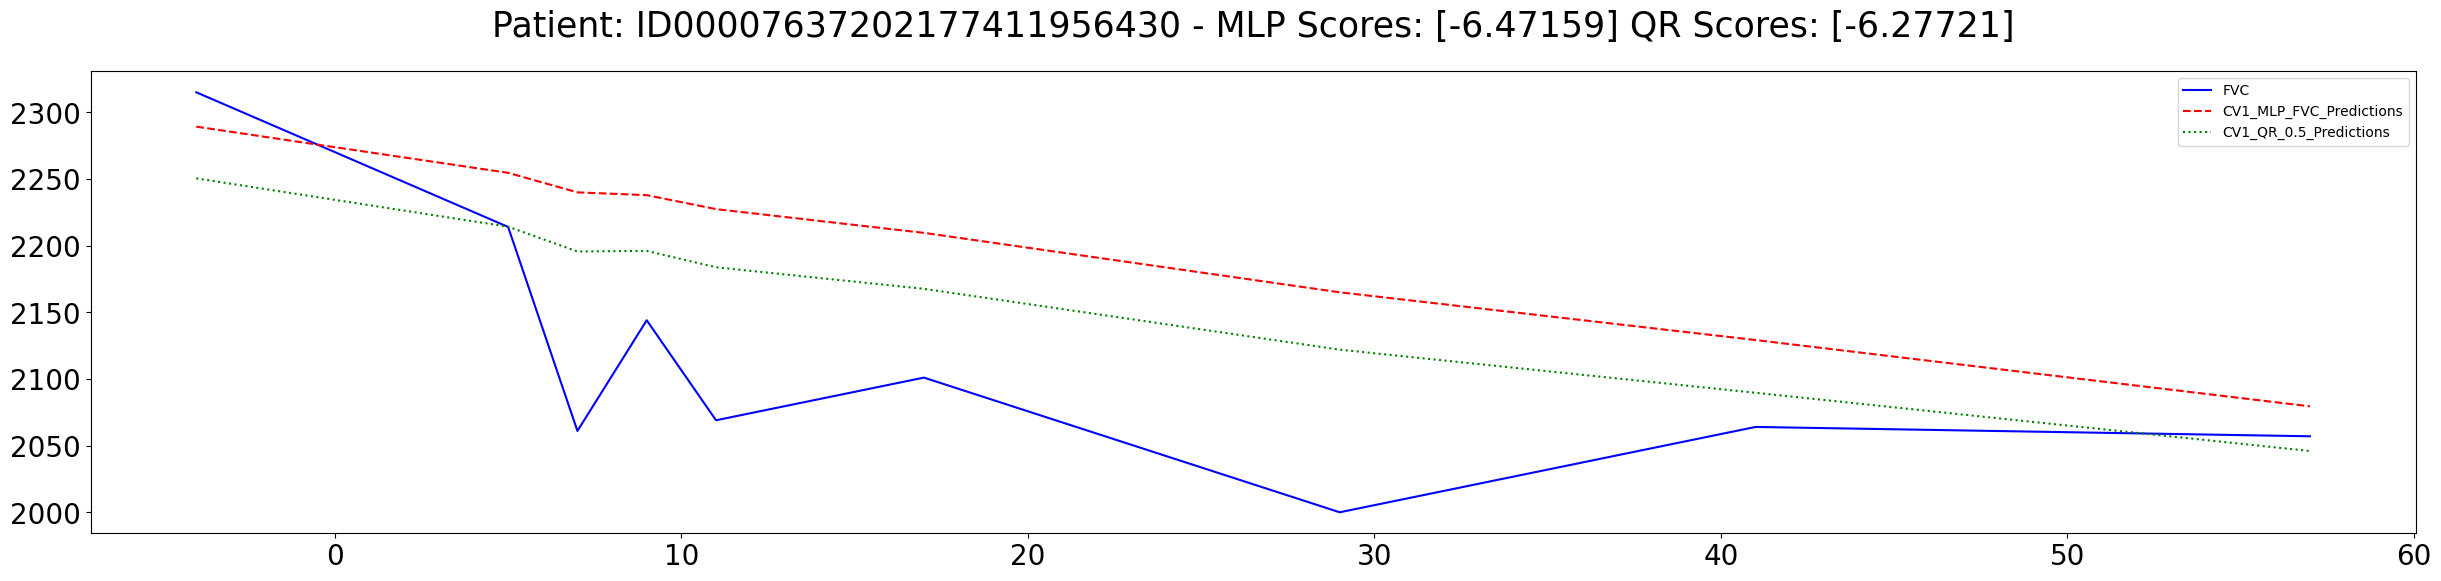

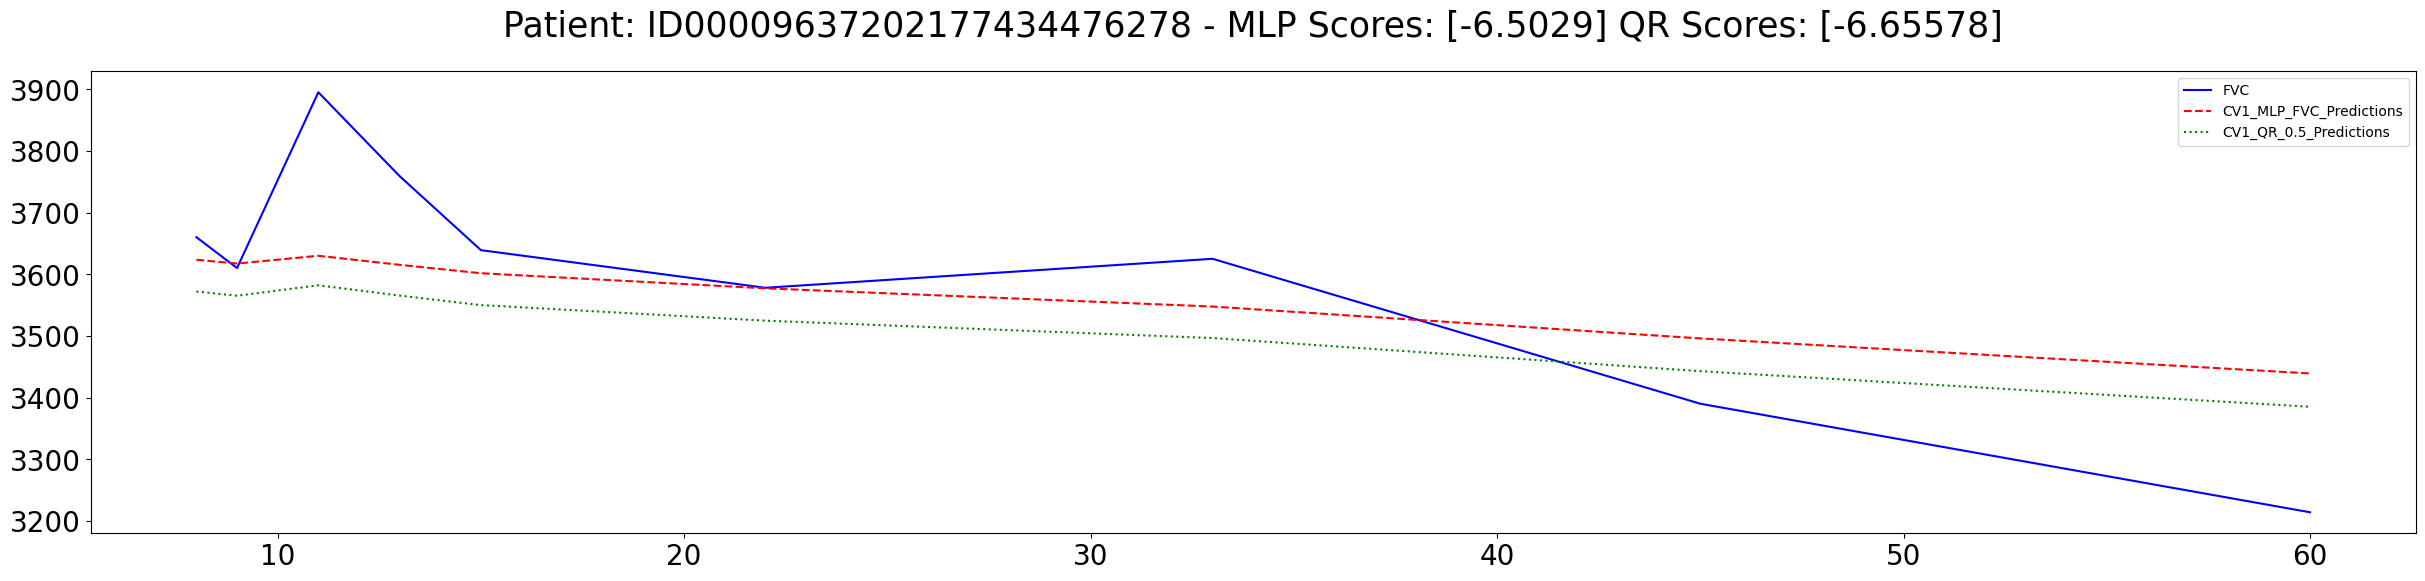

In [9]:
# Optional quick plot for a few patients (kept but should not crash now)
for patient, dfp in list(df_train.groupby("Patient"))[:2]:
    qr_mlp.plot_predictions(dfp, patient)




In [10]:
class SubmissionPipeline:

    def __init__(self, df_train, df_test):
        self.df_train = df_train
        self.df_test = df_test

    def laplace_log_likelihood_metric(self, y_true, y_pred, sigma):
        sigma_clipped = np.maximum(sigma, 70)
        delta_clipped = np.minimum(np.abs(y_true - y_pred), 1000)
        score = -np.sqrt(2) * delta_clipped / sigma_clipped - np.log(
            np.sqrt(2) * sigma_clipped
        )
        return np.mean(score)

    def single_model(self, model):
        self.df_test["Patient_Week"] = (
            self.df_test["Patient"].astype(str)
            + "_"
            + self.df_test["Weeks"].astype(str)
        )

        prediction_cols = [
            col for col in self.df_train.columns if col.startswith(model)
        ]
        if model.split("_")[1] == "MLP":
            score = self.laplace_log_likelihood_metric(
                self.df_train["FVC"],
                self.df_train[prediction_cols[0]],
                self.df_train[prediction_cols[1]],
            )
            print(f"Single Model {model} Score: {score:.6}")
            self.df_test["FVC"] = self.df_test[prediction_cols[0]]
            self.df_test["Confidence"] = self.df_test[prediction_cols[1]]

        elif model.split("_")[1] == "QR":
            score = self.laplace_log_likelihood_metric(
                self.df_train["FVC"],
                self.df_train[prediction_cols[1]],
                (self.df_train[prediction_cols[2]] - self.df_train[prediction_cols[0]]),
            )
            print(f"Single Model {model} Score: {score:.6}")
            self.df_test["FVC"] = self.df_test[prediction_cols[1]]
            self.df_test["Confidence"] = (
                self.df_test[prediction_cols[2]] - self.df_test[prediction_cols[0]]
            )

        print(f'\n{self.df_test[["FVC", "Confidence"]].describe()}')
        return self.df_test[["Patient_Week", "FVC", "Confidence"]].copy(deep=True)

    def blend(self, by, model, cv):
        self.df_test["Patient_Week"] = (
            self.df_test["Patient"].astype(str)
            + "_"
            + self.df_test["Weeks"].astype(str)
        )

        if by == "cv":
            quantiles = [0.2, 0.5, 0.8]
            for df in [self.df_train, self.df_test]:
                df[f"CV{cv}_FVC"] = (df[f"CV{cv}_MLP_FVC_Predictions"] * 0.5) + (
                    df[f"CV{cv}_QR_{quantiles[1]}_Predictions"] * 0.5
                )
                df[f"CV{cv}_Confidence"] = (
                    df[f"CV{cv}_MLP_Confidence_Predictions"] * 0.5
                ) + (
                    (
                        df[f"CV{cv}_QR_{quantiles[2]}_Predictions"]
                        - df[f"CV{cv}_QR_{quantiles[0]}_Predictions"]
                    )
                    * 0.5
                )

            score = self.laplace_log_likelihood_metric(
                self.df_train["FVC"],
                self.df_train[f"CV{cv}_FVC"],
                self.df_train[f"CV{cv}_Confidence"],
            )
            single_model_scores = [
                round(
                    self.laplace_log_likelihood_metric(
                        self.df_train["FVC"],
                        self.df_train[f"CV{cv}_MLP_FVC_Predictions"],
                        self.df_train[f"CV{cv}_MLP_Confidence_Predictions"],
                    ),
                    6,
                ),
                round(
                    self.laplace_log_likelihood_metric(
                        self.df_train["FVC"],
                        self.df_train[f"CV{cv}_QR_{quantiles[1]}_Predictions"],
                        (
                            self.df_train[f"CV{cv}_QR_{quantiles[2]}_Predictions"]
                            - self.df_train[f"CV{cv}_QR_{quantiles[0]}_Predictions"]
                        ),
                    ),
                    6,
                ),
            ]
            print(
                f"CV{cv} Blend Score: {score:.6} - Single Model Scores: {single_model_scores}"
            )

            self.df_test["FVC"] = self.df_test[f"CV{cv}_FVC"]
            self.df_test["Confidence"] = self.df_test[f"CV{cv}_Confidence"]

        print(f'\n{self.df_test[["FVC", "Confidence"]].describe()}')
        return self.df_test[["Patient_Week", "FVC", "Confidence"]].copy(deep=True)




In [11]:
sub = SubmissionPipeline(df_train, df_test)
df_submission_out = sub.blend(by="cv", model=None, cv=1)

# Metric clips sigma at 70 in scoring; ensure non-negative confidence and a reasonable floor for stability.
df_submission_out["Confidence"] = df_submission_out["Confidence"].clip(lower=70)

# Ensure integer-like FVC and proper columns/order
df_submission_out["FVC"] = df_submission_out["FVC"].astype(np.float32)
df_submission_out = df_submission_out[["Patient_Week", "FVC", "Confidence"]]

df_submission_out.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", df_submission_out.shape)
print(df_submission_out.head())



CV1 Blend Score: -6.63747 - Single Model Scores: [-6.634062, -6.651486]

               FVC   Confidence
count  1908.000000  1908.000000
mean   2939.812256   299.398346
std    1051.523071   106.915138
min    1377.804932    64.493805
25%    2147.296631   225.679344
50%    3002.900513   290.874939
75%    3396.434082   352.353386
max    6366.546875   670.748901
Wrote submission.csv with shape: (1908, 3)
                   Patient_Week          FVC  Confidence
0  ID00126637202218610655908_-3  2394.354492  169.551880
1  ID00126637202218610655908_-2  2391.652832  171.095551
2  ID00126637202218610655908_-1  2388.951172  172.638733
3   ID00126637202218610655908_0  2386.249512  174.182159
4   ID00126637202218610655908_1  2383.541260  175.724838


In [12]:
df_submission_out

,Patient_Week,FVC,Confidence
0,ID00126637202218610655908_-3,2394.354492,169.551880
1,ID00126637202218610655908_-2,2391.652832,171.095551
2,ID00126637202218610655908_-1,2388.951172,172.638733
3,ID00126637202218610655908_0,2386.249512,174.182159
4,ID00126637202218610655908_1,2383.541260,175.724838
...,...,...,...
1903,ID00047637202184938901501_98,3010.818848,432.539520
1904,ID00047637202184938901501_99,3007.832275,434.201080
1905,ID00047637202184938901501_100,3005.077148,435.673462
1906,ID00047637202184938901501_101,3002.342529,437.130493
